In [1]:
import importlib, sys
sys.path.append('./src')

import numpy as np
import matplotlib.pyplot as plt

In [2]:
from attention import MultiHeadAttention

np.random.seed(42)
d_model = 64
num_heads = 8
seq_len = 6

mha = MultiHeadAttention(d_model, num_heads)

x = np.random.randn(seq_len, d_model)
output, attn_weights = mha.forward(x, x, x)

print("Output shape:", output.shape)          # (6, 64)
print("Attn weights shape:", attn_weights.shape)  # (8, 6, 6)

Output shape: (6, 64)
Attn weights shape: (8, 6, 6)


PE shape: (50, 64)


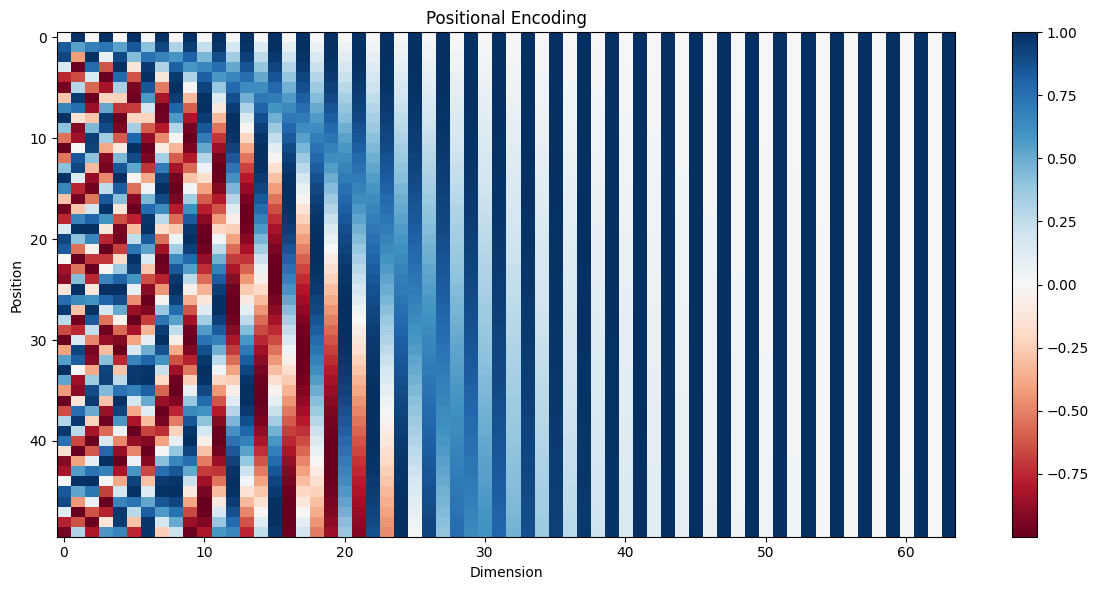

In [3]:
from positional_encoding import positional_encoding

seq_len = 50
d_model = 64

PE = positional_encoding(seq_len, d_model)

print("PE shape:", PE.shape)  # (50, 64)

plt.figure(figsize=(12, 6))
plt.imshow(PE, cmap='RdBu', aspect='auto')
plt.colorbar()
plt.title("Positional Encoding")
plt.xlabel("Dimension")
plt.ylabel("Position")
plt.tight_layout()
plt.show()

In [ ]:
from feedforward import FeedForward

d_model = 64
d_ff = 256

ff = FeedForward(d_model, d_ff)
x = np.random.randn(6, d_model)
output = ff.forward(x)

print("Input shape:", x.shape)     # (6, 64)
print("Output shape:", output.shape)  # (6, 64)

Input shape: (6, 64)
Output shape: (6, 64)


In [6]:
from layer_norm import LayerNorm

ln = LayerNorm(d_model)
x = np.random.randn(6, d_model)
output = ln.forward(x)

print("Output shape:", output.shape)        # (6, 64)
print("Mean (≈0):", np.mean(output, axis=-1).round(6))
print("Std  (≈1):", np.std(output, axis=-1).round(6))

Output shape: (6, 64)
Mean (≈0): [-0. -0.  0.  0. -0. -0.]
Std  (≈1): [0.999999 0.999999 0.999999 0.999999 0.999999 0.999999]


In [7]:
from encoder import Encoder

d_model = 64
num_heads = 8
d_ff = 256
num_layers = 6 

encoder = Encoder(d_model, num_heads, d_ff, num_layers)
x = np.random.randn(6, d_model)
output = encoder.forward(x)

print("Input shape:", x.shape)    # (6, 64)
print("Output shape:", output.shape)  # (6, 64)

Input shape: (6, 64)
Output shape: (6, 64)


In [8]:
from decoder import Decoder

decoder = Decoder(d_model, num_heads, d_ff, num_layers)

tgt = np.random.randn(5, d_model)
output = decoder.forward(tgt, output)

print("Target shape:", tgt.shape)     # (5, 64)
print("Output shape:", output.shape)  # (5, 64)

Target shape: (5, 64)
Output shape: (5, 64)


In [9]:
from transformer import Transformer

vocab_size = 1000
transformer = Transformer(d_model=512, num_heads=8, d_ff=2048, num_layers=6, vocab_size=vocab_size)

src = np.random.randn(10, 512)
tgt = np.random.randn(7, 512)

probs = transformer.forward(src, tgt)

print("Output shape:", probs.shape)              # (7, 1000)
print("Sum of probs (≈1):", probs[0].sum().round(6))  # sum of each row is 1

Output shape: (7, 1000)
Sum of probs (≈1): 1.0


In [10]:
# Simple test: check if Transformer produces valid output
# on a sequence sorting task (forward pass only)

np.random.seed(42)

vocab_size = 10  # digits 0-9
d_model = 512
seq_len = 6

# Create a random sequence of digits: e.g. [3, 1, 4, 1, 5, 9]
src_tokens = np.random.randint(0, vocab_size, size=seq_len)
print("Input sequence :", src_tokens)
print("Sorted sequence:", np.sort(src_tokens))

# Simple embedding: one-hot encode then project to d_model
def one_hot(tokens, vocab_size):
    one_hot = np.zeros((len(tokens), vocab_size))
    for i, t in enumerate(tokens):
        one_hot[i, t] = 1.0
    return one_hot

# Embed src and tgt
src_embed = one_hot(src_tokens, vocab_size)                    # (seq_len, vocab_size)
src_embed = np.pad(src_embed, ((0,0),(0, d_model - vocab_size)))  # (seq_len, d_model)

tgt_tokens = np.sort(src_tokens)
tgt_embed = one_hot(tgt_tokens, vocab_size)
tgt_embed = np.pad(tgt_embed, ((0,0),(0, d_model - vocab_size)))  # (seq_len, d_model)

# Forward pass
transformer = Transformer(d_model=d_model, num_heads=8, d_ff=2048, num_layers=6, vocab_size=vocab_size)
probs = transformer.forward(src_embed, tgt_embed)

# Predicted tokens (argmax over vocab)
predicted_tokens = np.argmax(probs, axis=-1)

print("\nTarget sequence :", tgt_tokens)
print("Predicted tokens:", predicted_tokens)
print("\n* Note: random weights, no training → predictions are random")
print("  This test only verifies the forward pass runs correctly.")

Input sequence : [6 3 7 4 6 9]
Sorted sequence: [3 4 6 6 7 9]

Target sequence : [3 4 6 6 7 9]
Predicted tokens: [3 3 3 3 3 3]

* Note: random weights, no training → predictions are random
  This test only verifies the forward pass runs correctly.
